# 3. Model track A - KNN & Logistic Regression

## 3.1. Thiết lập môi trường

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # notebooks/ -> gốc dự án
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

FIG_DIR = project_root / "figures" / "model_track_a"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

from src import data, metrics

## 3.2. Nạp dữ liệu đã xử lý

In [3]:
X, y, _ = data.load_processed()
fold = data.load_folds()

## 3.3. Tìm `n_neighbors` phù hợp cho KNN

Quét CV (5 fold dùng chung) qua một dải `n_neighbors` ứng cử, chọn giá trị cho log loss trung bình thấp nhất - giống cách chọn `max_depth` ở track B.

In [4]:
k_candidates = [3, 5, 7, 9, 11, 15, 21, 31, 41, 51]

k_rows = []
for k in k_candidates:
    for f, tr, va in data.iter_folds(fold):
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X.iloc[tr], y.iloc[tr])
        proba = model.predict_proba(X.iloc[va])
        k_rows.append({"n_neighbors": k, "fold": f, **metrics.compute_metrics(y.iloc[va], proba)})

k_scores = pd.DataFrame(k_rows)
k_summary = k_scores.groupby("n_neighbors")[metrics.METRIC_NAMES].mean()
k_summary

,log_loss,accuracy,macro_f1
n_neighbors,,,
3,3.519347,0.810729,0.559008
5,2.448201,0.816146,0.558674
7,2.006195,0.820729,0.549014
9,1.700382,0.822813,0.548957
11,1.510995,0.823958,0.545562
15,1.261799,0.822813,0.537043
21,1.008410,0.823750,0.532942
31,0.816374,0.820208,0.521866
41,0.711346,0.814896,0.518886


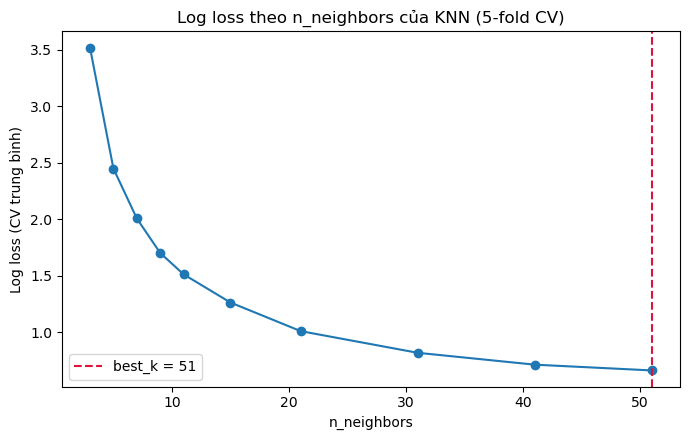

n_neighbors được chọn: 51


In [5]:
best_k = k_summary["log_loss"].idxmin()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k_summary.index, k_summary["log_loss"].values, marker="o")
ax.axvline(best_k, color="crimson", linestyle="--", label=f"best_k = {best_k}")
ax.set_xlabel("n_neighbors")
ax.set_ylabel("Log loss (CV trung bình)")
ax.set_title("Log loss theo n_neighbors của KNN (5-fold CV)")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "knn_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"n_neighbors được chọn: {best_k}")

## 3.4. Khai báo mô hình

`KNN` dùng `n_neighbors=best_k` (từ 3.3); không cần scaler vì `data.load_processed()` đã trả về dữ liệu scale sẵn. `Logistic Regression` dùng cấu hình mặc định cho bài toán đa lớp.

In [6]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=best_k),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=data.RANDOM_STATE),
}

## 3.5. Huấn luyện & đánh giá bằng Cross-Validation

Mỗi fold: `clone(base_model)` để train lại từ đầu, thu thập dự đoán out-of-fold (mục 3.8) và `coef_` của Logistic Regression (mục 3.9).

In [7]:
rows = []
oof_true = {name: [] for name in models}
oof_pred = {name: [] for name in models}
coefs = {name: [] for name in models}

for f, tr, va in data.iter_folds(fold):
    for name, base_model in models.items():
        model = clone(base_model)  # model mới
        model.fit(X.iloc[tr], y.iloc[tr])
        proba = model.predict_proba(X.iloc[va])

        rows.append({"model": name, "fold": f, **metrics.compute_metrics(y.iloc[va], proba)})
        oof_true[name].append(y.iloc[va])
        oof_pred[name].append(proba.argmax(axis=1))

        if hasattr(model, "coef_"):
            coefs[name].append(model.coef_)

scores = pd.DataFrame(rows)
scores.head()

,model,fold,log_loss,accuracy,macro_f1
0,KNN,0,0.638063,0.813542,0.515697
1,Logistic Regression,0,0.447164,0.828646,0.548372
2,KNN,1,0.737949,0.828646,0.530891
3,Logistic Regression,1,0.427159,0.842187,0.573244
4,KNN,2,0.628335,0.815104,0.515890


## 3.6. Lưu kết quả CV

In [8]:
scores.to_csv("../results/scores_track_a.csv", index=False)
scores

,model,fold,log_loss,accuracy,macro_f1
0,KNN,0,0.638063,0.813542,0.515697
1,Logistic Regression,0,0.447164,0.828646,0.548372
2,KNN,1,0.737949,0.828646,0.530891
3,Logistic Regression,1,0.427159,0.842187,0.573244
4,KNN,2,0.628335,0.815104,0.515890
5,Logistic Regression,2,0.435752,0.832292,0.569577
6,KNN,3,0.601946,0.802604,0.501381
7,Logistic Regression,3,0.448314,0.830729,0.559557
8,KNN,4,0.695030,0.810937,0.513496
9,Logistic Regression,4,0.444156,0.831250,0.539081


## 3.7. Bảng tổng hợp kết quả (mean ± std)

In [9]:
summary = metrics.summarize_scores(scores)
summary

log_loss            accuracy            macro_f1  \
                         mean       std      mean       std      mean   
model                                                                   
KNN                  0.660265  0.055129  0.814167  0.009421  0.515471   
Logistic Regression  0.440509  0.008935  0.833021  0.005294  0.557966   

                               
                          std  
model                          
KNN                  0.010493  
Logistic Regression  0.014313

## 3.8. Confusion Matrix (Out-of-Fold)

Dự đoán out-of-fold gộp 5 fold, chuẩn hóa theo hàng (`normalize="true"`).

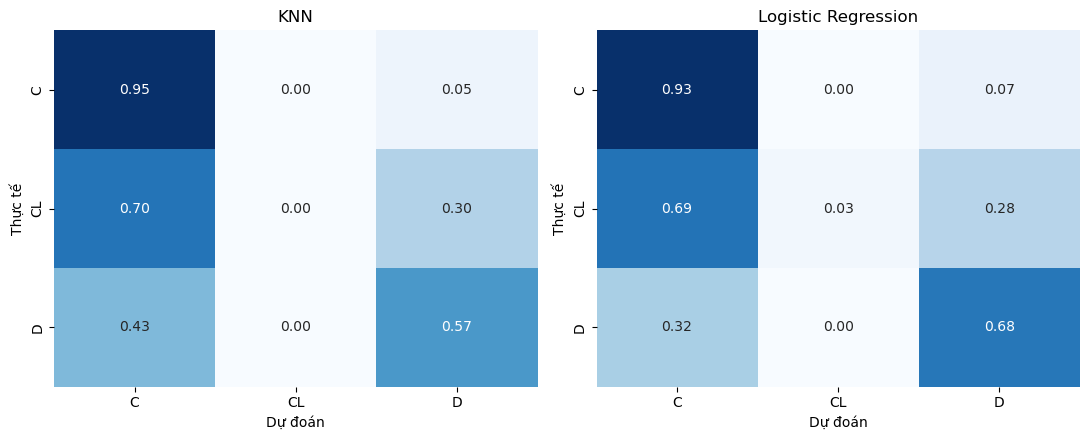

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, models):
    y_true_all = pd.concat(oof_true[name])
    y_pred_all = np.concatenate(oof_pred[name])
    cm = confusion_matrix(y_true_all, y_pred_all, labels=data.LABELS, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=data.CLASS_ORDER, yticklabels=data.CLASS_ORDER, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
plt.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.9. Phân tích hệ số hồi quy (Logistic Regression Coefficients)

KNN không có `feature_importances_`/`coef_` nên không xuất hiện ở đây. Với Logistic Regression, lấy `|coef_|` trung bình qua 3 lớp và 5 fold làm đại lượng tương đương "độ quan trọng đặc trưng".

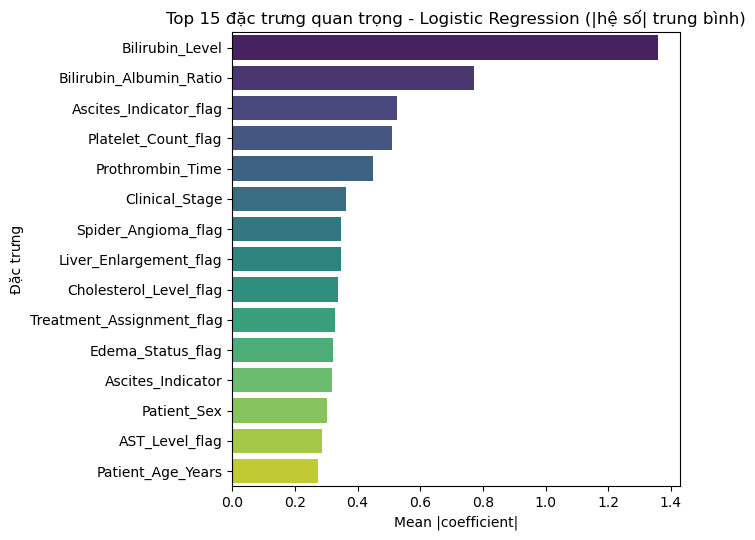

In [11]:
lr_mean_coef = np.mean(np.abs(coefs["Logistic Regression"]), axis=0).mean(axis=0)
imp_df = pd.DataFrame({"feature": X.columns, "importance": lr_mean_coef})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, hue="feature", legend=False, palette="viridis")
ax.set_title("Top 15 đặc trưng quan trọng - Logistic Regression (|hệ số| trung bình)")
ax.set_xlabel("Mean |coefficient|")
ax.set_ylabel("Đặc trưng")
plt.tight_layout()
fig.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.10. So sánh trực quan giữa 2 mô hình

So sánh trung bình 3 chỉ số (log loss, accuracy, macro-F1) qua 5 fold.

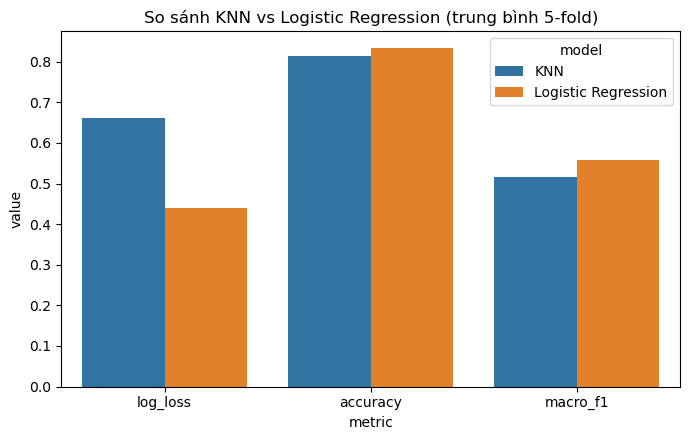

In [12]:
plot_df = summary.xs("mean", axis=1, level=1).reset_index()
plot_df = plot_df.melt(id_vars="model", var_name="metric", value_name="value")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=plot_df, x="metric", y="value", hue="model", ax=ax)
ax.set_title("So sánh KNN vs Logistic Regression (trung bình 5-fold)")
plt.tight_layout()
fig.savefig(FIG_DIR / "metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.11. Nhận xét

- **n_neighbors:** log loss giảm đơn điệu từ 3.519 (`k=3`) xuống 0.660 (`k=51`, chọn), trong khi accuracy/macro-F1 gần như không đổi. Nguyên nhân: `k` nhỏ khiến nhiều điểm nhận xác suất 0 tuyệt đối ở lớp đúng, bị log loss phạt nặng.
- **KNN vs Logistic Regression:** Logistic Regression thắng cả 3 chỉ số - log loss **0.441±0.009** so với **0.660±0.055**, accuracy **0.833±0.005** so với **0.814±0.009**, macro-F1 **0.558±0.014** so với **0.515±0.010** - và ổn định hơn nhiều giữa các fold.
- **Hệ số hồi quy:** `Bilirubin_Level` (≈1.36), `Bilirubin_Albumin_Ratio` (≈0.77), `Ascites_Indicator_flag` (≈0.52), `Platelet_Count_flag` (≈0.51), `Prothrombin_Time` (≈0.45) - trùng nhóm chỉ số gan mà track B cũng xác định là mạnh nhất.
- **Kết luận:** **Logistic Regression** là lựa chọn tốt hơn cho Track A, đặc biệt ở log loss - chỉ số chính của cuộc thi.